In [1]:
from itertools import product
from pathlib import Path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [11]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [3]:
batch_ranges = {
    (100, 1): (0, 1),
    (200, 1): (0, 2),
    (400, 1): (0, 4),
    (800, 1): (0, 8),
    (1600, 1): (0, 16),
    (100, 2): (8, 9),
    (200, 2): (8, 10),
    (400, 2): (8, 12),
    (800, 2): (8, 16),
    (1600, 2): (0, 16),
}

In [4]:
# load the full training logs for each run
tables = []
for n, t in batch_ranges:
    key = f"n{n}_{t}"
    log_path = Path(f"output/data_scaling/{key}/pretrain/log.json")
    table = pd.read_json(log_path, lines=True)
    assert len(table) == 100, f"incomplete run {key}"
    table.insert(0, "trial", t)
    table.insert(0, "num_shards", n)
    table.insert(0, "run", key)
    tables.append(table)

train_logs = pd.concat(tables, ignore_index=True)
train_logs["hcp-val/loss"] = train_logs["eval/hcp-val/loss"]
train_logs["nsd-val/loss"] = train_logs["eval/nsd-val/loss"]
train_logs = train_logs.loc[
    :, ["run", "num_shards", "trial", "epoch", "hcp-val/loss", "nsd-val/loss"]
]
print(train_logs.shape)
train_logs.head()

(1000, 6)


,run,num_shards,trial,epoch,hcp-val/loss,nsd-val/loss
0,n100_1,100,1,0,0.990444,0.990427
1,n100_1,100,1,1,0.988416,0.990074
2,n100_1,100,1,2,0.981571,0.986203
3,n100_1,100,1,3,0.975086,0.982094
4,n100_1,100,1,4,0.927232,0.903293


In [5]:
# downstream analysis
num_shards = [1600]

tables = []
for n, t in product(num_shards, [1, 2]):
    key = f"n{n}_{t}"
    paths = sorted(Path(f"output/data_scaling/{key}/eval").rglob("*__0*/eval_table.csv"))
    for path in paths:
        epoch = int(path.parts[-2].split("__")[-1])
        table = pd.read_csv(path)
        table = table.loc[table["split"] == "test", ["dataset", "acc", "acc_std"]]
        table.insert(0, "epoch", epoch)
        table.insert(0, "trial", t)
        table.insert(0, "num_shards", n)
        table.insert(0, "run", key)
        tables.append(table)
table = pd.concat(tables, ignore_index=True)

table = table.pivot_table(
    values=["acc", "acc_std"],
    index=["run", "num_shards", "trial", "epoch"],
    columns="dataset",
)
table = table.reset_index()

table.columns = ["run", "num_shards", "trial", "epoch"] + [
    f"{ds}/{metric}" for metric, ds in product(["acc", "acc_std"], ["aabc_age", "nsd_cococlip"])
]

table = train_logs.merge(table, how="inner", on=["run", "num_shards", "trial", "epoch"])
table = table.iloc[:, 2:]
print(table.shape)
table.head(10)

(40, 8)


,trial,epoch,hcp-val/loss,nsd-val/loss,aabc_age/acc,nsd_cococlip/acc,aabc_age/acc_std,nsd_cococlip/acc_std
0,1,4,0.918366,0.887942,0.269231,0.257328,0.057567,0.004863
1,1,9,0.851714,0.817580,0.326923,0.294805,0.060739,0.005461
2,1,14,0.844361,0.812874,0.307692,0.291837,0.059529,0.005116
3,1,19,0.841504,0.811804,0.346154,0.267904,0.064697,0.005280
4,1,24,0.839881,0.812248,0.423077,0.260297,0.063829,0.005186
5,1,29,0.839214,0.811595,0.384615,0.274212,0.064922,0.004979
6,1,34,0.839125,0.815410,0.384615,0.265121,0.061495,0.005396
7,1,39,0.837438,0.809175,0.288462,0.302041,0.062843,0.005434
8,1,44,0.836554,0.819372,0.346154,0.292393,0.064882,0.005257
9,1,49,0.835510,0.810582,0.384615,0.300742,0.063095,0.005380


In [6]:
table_avg = table.iloc[:, 1:6].groupby("epoch").mean()
table_avg = table_avg.rolling(4, min_periods=1).mean()

In [34]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

```
['#0072B2', '#009E73', '#E69F00', '#D55E00', '#CC79A7', '#845B97', '#56B4E9', '#F0E442', '#474747']
```

In [35]:
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
print(color_cycle)

['#0072B2', '#009E73', '#E69F00', '#D55E00', '#CC79A7', '#845B97', '#56B4E9', '#F0E442', '#474747']


aabc_age/acc 0.029
nsd_cococlip/acc 0.009


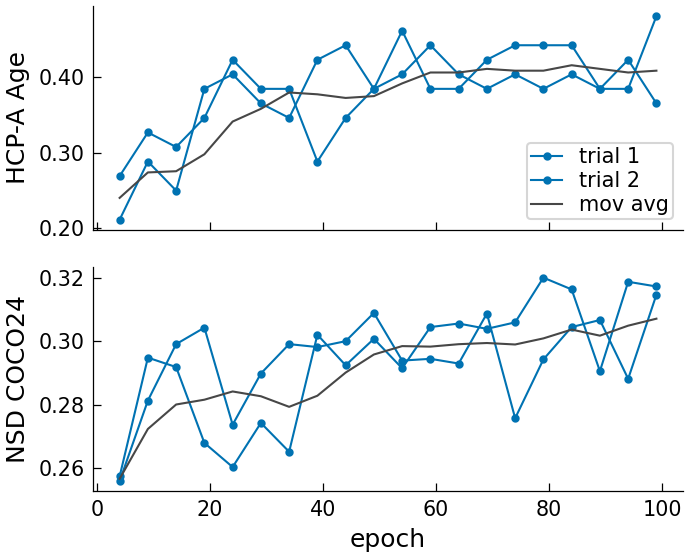

In [40]:
from matplotlib.ticker import FormatStrFormatter

metrics = [
    # "hcp-val/loss",
    # "nsd-val/loss",
    "aabc_age/acc",
    "nsd_cococlip/acc",
]

labels = {
    "hcp-val/loss": "loss (HCP-YA)",
    "nsd-val/loss": "loss (NSD)",
    "aabc_age/acc": "HCP-A Age",
    "nsd_cococlip/acc": "NSD COCO24",
}


nr = len(metrics)
nc = 1
ploth = 1.0
plotw = 0.75 * PLOTW

f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, nr * ploth), sharex=True)

for ii, metric in enumerate(metrics):
    ax = axs[ii]
    plt.sca(ax)

    ys = []
    for trial in [1, 2]:
        sub_table = table.query(f"trial == {trial}")
        x = sub_table["epoch"]
        y = sub_table[metric]
        plt.plot(x, y, "o-", color=color_cycle[0], label=f"trial {trial}")
        ys.append(y)
    ys = np.stack(ys, axis=1)

    x = table_avg.index
    y = table_avg[metric]
    plt.plot(x, y, "-", color=color_cycle[-1], label="mov avg")
    plt.ylabel(labels[metric])
    if (ii + 1) == len(metrics):
        plt.xlabel("epoch")

    std = np.std(ys - ys.mean(axis=1, keepdims=True))
    # plt.fill_between(x, y - 2 * std, y + 2 * std, color="b", alpha=0.2, lw=0.0)
    print(f"{metric} {std:.3f}")

    ax.yaxis.set_major_formatter(FormatStrFormatter("%0.2f"))

    if ii == 0:
        ax.legend()

plt.tight_layout()